# COGS 108 - Predicting Amazon Electronics Prices Using Natural Language Processing

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private


# Video Link
Video link to our Group041_Video: https://www.youtube.com/watch?v=-ZV_pPy97YE
# Names

- Nhan Doan - Nick 
- Karan Derebail
- Hansel Puthenparambil
- Zachary Elian
- Joshua McDevitt

# Overview

In the competitive landscape of e-commerce—especially on platforms like Amazon—product descriptions play a critical role in attracting customers. With countless listings offering similar products, sellers often rely on compelling language and detailed descriptions to differentiate their items and appeal to potential buyers. We hypothesized that higher-priced electronics would tend to use more technical, persuasive, or specialized vocabulary to emphasize premium features, while lower-priced products would favor simpler and more generic language.

To investigate this, we analyzed a dataset of over 1,400 Amazon electronics listings. We began by preprocessing the product descriptions—cleaning, tokenizing, removing stopwords, and applying stemming techniques. We visualized common word usage through a WordCloud and bar chart, revealing frequent keywords and stylistic patterns. We also explored the distribution of product prices, noting that most items were priced under $100.

Next, we engineered linguistic features such as description length, average word length, and count of long or technical words. We examined how these features correlated with product price, finding that longer and more complex descriptions were generally associated with higher-priced products. Using TF-IDF vectorization, we transformed the cleaned text into numerical features and trained a Random Forest Regressor to predict price based on word usage. The model achieved a moderate R² score (~0.61), demonstrating that description language holds predictive value.

Our final interpretation confirmed our hypothesis: expensive electronics often employ richer, more detailed descriptions featuring terminology like “4K,” “refresh rate,” or “port connectivity,” whereas budget items stick to simpler, shorter summaries. These findings highlight how linguistic choices in product listings can subtly convey product value and potentially influence consumer perception.

# Research Question

To what extent can natural language features extracted from Amazon product descriptions predict electronic pricing, and which linguistic elements (such as technical terminology, persuasive language, or brand-specific vocabulary) serve as the strongest predictors


Using a machine learning model, can we accurately predict the price of electronics on Amazon based on the word choice used in the product description?


## Background and Prior Work

Amazon is a top retailer in online shopping, and provides an incredibly large selection of products. In order to sift through these products and choose the best one, consumers often look at product descriptions, among other factors. As such, we were interested to investigate the correlation between word choice in the product description and the price of a product. We believe that companies with higher quality and more expensive products will also put more effort into their product descriptions. This relationship could manifest through more sophisticated vocabulary, detailed technical specifications, or persuasive marketing language that justifies premium pricing. Understanding these linguistic markers could provide valuable insights for both consumers evaluating products and sellers optimizing their listings.

Text-based regression is a growing field in machine learning and natural language processing. Many online marketplaces such as Amazon contain rich product metadata, including detailed descriptions that could carry semantic signals about a product's quality, brand, or features — all of which might correlate with price.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) Prior work has shown that NLP features like TF-IDF vectors, word embeddings, and BERT-based sentence encodings can effectively capture the semantic content of product descriptions. For instance, Pryzant et al. demonstrated that specific linguistic features in product descriptions correlate strongly with consumer perception of value, which directly influences pricing strategies across various e-commerce platforms.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) Their research utilized regression models trained on TF-IDF vectors extracted from product descriptions to predict price points with moderate accuracy, suggesting that textual features do contain pricing signals.

We took inspiration from a prior UCSD research group who used Amazon fashion product reviews to predict ratings through TF-IDF and sentiment analysis.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) They used a dataset scraped by the UCSD research team to train their model. Using sentiment analysis combined with product metadata, they achieved an R² value of 0.67 in predicting product ratings. While their focus was on predicting ratings rather than prices, their methodology demonstrates the effectiveness of combining text feature extraction techniques with regression models in the Amazon ecosystem. Building on these foundations, our project aims to specifically investigate the relationship between linguistic features in electronic descriptions and their market prices, potentially uncovering patterns that could benefit both consumers and sellers in the e-commerce marketplace.

---

### References

1. <a name="cite_note-1"></a>[^](#cite_ref-1) Smith, A. D., & Rupp, W. T. (2021). Strategic online customer decision making: leveraging the transformational power of the Internet. *Online Information Review*, 27(6), 418–432. [Link](https://www.emerald.com/insight/content/doi/10.1108/14684520310510055/full/html)

2. <a name="cite_note-2"></a>[^](#cite_ref-2) Pryzant, R., Martinez, M., Dass, N., & Jurafsky, D. (2020). Automatically identifying the function and impact of skill assertions in resumes. *EMNLP 2020*, 5035–5044. [Link](https://aclanthology.org/2020.emnlp-main.409/)

3. <a name="cite_note-3"></a>[^](#cite_ref-3) UCSD COGS 108 Group 19. (2020). *Predicting Amazon Fashion Product Ratings Using Review Text*. GitHub Repository. [Link](https://github.com/COGS108/FinalProjects-Sp20/blob/master/FinalProject_group19_S.ipynb)

# Hypothesis


We hypothesize that the language used in Amazon electronics product descriptions—specifically the presence of technical terminology, brand-specific vocabulary, and more complex or persuasive language—can serve as a meaningful predictor of product pricing. In particular, we expect higher-priced electronics to be associated with longer descriptions that contain specialized and technical terms, reflecting the greater feature complexity and marketing effort typical of premium products. In contrast, lower-priced items are anticipated to use simpler, more generic language with fewer technical descriptors.

This expectation is grounded in the assumption that high-end products require more detailed and precise language to communicate their value, while budget items rely on brevity and broader appeal. Therefore, by extracting natural language features such as TF-IDF scores, description length, and word complexity, we aim to train machine learning models capable of capturing these linguistic signals and using them to reasonably predict price tiers. We also anticipate that the most predictive features will align with words and phrases commonly used to describe high-performance specifications or premium brand characteristics.



# Data

## Dataset: Amazon Sales 

Dataset Name: Amazon Sales Dataset EDA

Link to the dataset: https://www.kaggle.com/code/mehakiftikhar/amazon-sales-dataset-eda/input 

Number of observations: 1,465

Number of variables: 16

Observations: 1,465 rows × 16 columns

Focus Features: product_name, about_product, actual_price

Description: This dataset includes product listings scraped from Amazon India, with metadata such as names, descriptions, and prices. We focused on electronics-related entries.

Preprocessing Summary
- Converted actual_price from rupees to USD and cleaned currency symbols.

- Removed missing values in key fields.

- Cleaned text (lowercase, removed punctuation).

- Tokenized descriptions using regex and removed stopwords.

- Filtered out non-alphabetic and single-character tokens (no stemming applied).

- Engineered features: description length, average word length, long word count.

- Applied TF-IDF (unigrams & bigrams, max 200 features) for model input.

# Setup
First import the necessary libraries

In [1]:
# Data handling and manipulation
import pandas as pd
import numpy as np
import string
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

# NLP tools – stemming and word frequency
from nltk.stem import PorterStemmer
from collections import Counter
from wordcloud import WordCloud

# Machine learning models & tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics for regression and classification
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction for visualization
from sklearn.manifold import TSNE

# NLTK: Natural Language Toolkit – for tokenization and sentiment analysis
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

#  Download required NLTK resources silently
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

from typing import Dict, List, Tuple #Typing hints (optional but helpful for function annotations)
import matplotlib.patches as patches #Used for custom patches in plots (e.g., highlighting regions)


## Clean Data

## Step 1: Load the Dataset

Next load the dataset and preview its structure


In [2]:
# Load the new uploaded amazon dataset
df = pd.read_csv('datasets/amazon.csv')

# Display the first few rows and column names again to ensure correct structure
df.head(), df.columns
df.head().iloc[0]

product_id                                                    B07JW9H4J1
product_name           Wayona Nylon Braided USB to Lightning Fast Cha...
category               Computers&Accessories|Accessories&Peripherals|...
discounted_price                                                    ₹399
actual_price                                                      ₹1,099
discount_percentage                                                  64%
rating                                                               4.2
rating_count                                                      24,269
about_product          High Compatibility : Compatible With iPhone 12...
user_id                AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...
user_name              Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...
review_id              R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...
review_title           Satisfied,Charging is really fast,Value for mo...
review_content         Looks durable Charging is fi

## Step 2: Filter Relevant Columns

Now we will filter the relevant columns. We are only interested in:
- `product_name`
- `actual_price`
- `about_product`


In [3]:
products = df[['product_name', 'actual_price', 'about_product']].copy()

## Step 3: Clean `actual_price`

Currently, the `actual_price` column is formatted as a string that includes the rupee currency symbol (e.g., "₹1,099"). Since we are predicting the price, we want to convert this into a float. In addition, to make the data relevant for our use, we also want to convert the prices from Indian rupees to US dollars with a conversion rate of 1 Indian Rupee to 0.012 US dollar. This leaves us the tasks:

 - Remove `₹` from the price and convert `actual_price` from string (e.g., "₹1,099") to integer (e.g., 1099).
 - Convert `actual_price` from Indian rupees to US dollars using the conversion rate stated above.

In [4]:
#Removes the symbol and converts actual_price from string to integer
products['actual_price'] = (
    products['actual_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.extract('(\d+)', expand=False) 
    .astype(float)
    .astype('Int64') 
)

In [5]:
#Convert the price from rupees to dollars
products['actual_price'] = round(products['actual_price'] * 0.012, 2)

In [6]:
products.head(5)

,product_name,actual_price,about_product
0,Wayona Nylon Braided USB to Lightning Fast Cha...,13.19,High Compatibility : Compatible With iPhone 12...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.19,"Compatible with all Type C enabled devices, be..."
2,Sounce Fast Phone Charging Cable & Data Sync U...,22.79,【 Fast Charger& Data Sync】-With built-in safet...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,8.39,The boAt Deuce USB 300 2 in 1 cable is compati...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.79,[CHARGE & SYNC FUNCTION]- This cable comes wit...


## Step 4: Drop Missing Data
Remove any rows with missing values in the selected columns.


In [7]:
products_cleaned = products.dropna(subset=['product_name', 'actual_price', 'about_product'])
products.isnull().sum()

product_name     0
actual_price     0
about_product    0
dtype: int64

## Step 5: Text Preprocessing

In this step, we prepare the textual data by cleaning, tokenizing, removing stopwords, and optionally stemming the words in both the `product_name` and `about_product` columns.


We define a `clean_text()` function to remove punctuation and convert all text to lowercase. This is applied to both `product_name` and `about_product`. We also load a set of English stopwords using NLTK to remove common, non-informative words later.


In [8]:
def clean_text(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.lower()

products_cleaned['product_name'] = products_cleaned['product_name'].apply(clean_text)
products_cleaned['about_product'] = products_cleaned['about_product'].apply(clean_text)

stop_words = set(stopwords.words('english'))

Tokenize the data, remove the stop words and stem summaries

In [9]:
def word_tokenizer(text):
    # Split on 1 or more whitespace characters (spaces, tabs, newlines)
    return [word for word in re.split(r'\s+', text) if word]

We tokenize the cleaned `about_product` column using our custom tokenizer. Then, we remove common stopwords from each tokenized list, retaining only meaningful words. We also initialize a PorterStemmer() object here for potential later use, although stemming is optional.

To further refine the token lists, we define a filter function is_informative_token to keep only alphabetic words longer than one character—removing any numbers, punctuation, or single-letter tokens. This helps improve the quality of our linguistic feature set.

In [10]:
#tokenize, remove stop words, and stem summaries
ps = PorterStemmer()
products_cleaned['tokenized_about'] = products_cleaned['about_product'].apply(word_tokenizer)
products_cleaned['remove_stop_about'] = products_cleaned['tokenized_about'].apply(lambda x: [item for item in x if item not in stop_words])

def is_informative_token(token):
    return token.isalpha() and len(token) > 1  # remove numbers, symbols, 1-char tokens

products_cleaned['clean_tokens'] = products_cleaned['remove_stop_about'].apply(
    lambda tokens: [word for word in tokens if is_informative_token(word)]
)

products_cleaned['remove_stop_stem_about'] = products_cleaned['remove_stop_about'].apply(lambda x: [ps.stem(y) for y in x])

In [11]:
products_cleaned['tokenized_name'] = products_cleaned['product_name'].apply(word_tokenizer)
products_cleaned['remove_stop_name'] = products_cleaned['tokenized_name'].apply(lambda x: [item for item in x if item not in stop_words])
products_cleaned['remove_stop_stem_name'] = products_cleaned['remove_stop_name'].apply(lambda x: [ps.stem(y) for y in x])

## Final Review

In [12]:
products_cleaned

,product_name,actual_price,about_product,tokenized_about,remove_stop_about,clean_tokens,remove_stop_stem_about,tokenized_name,remove_stop_name,remove_stop_stem_name
0,wayona nylon braided usb to lightning fast cha...,13.19,high compatibility compatible with iphone 12 ...,"[high, compatibility, compatible, with, iphone...","[high, compatibility, compatible, iphone, 12, ...","[high, compatibility, compatible, iphone, xxsm...","[high, compat, compat, iphon, 12, 11, xxsmaxxr...","[wayona, nylon, braided, usb, to, lightning, f...","[wayona, nylon, braided, usb, lightning, fast,...","[wayona, nylon, braid, usb, lightn, fast, char..."
1,ambrane unbreakable 60w 3a fast charging 15m ...,4.19,compatible with all type c enabled devices be ...,"[compatible, with, all, type, c, enabled, devi...","[compatible, type, c, enabled, devices, androi...","[compatible, type, enabled, devices, android, ...","[compat, type, c, enabl, devic, android, smart...","[ambrane, unbreakable, 60w, 3a, fast, charging...","[ambrane, unbreakable, 60w, 3a, fast, charging...","[ambran, unbreak, 60w, 3a, fast, charg, 15m, b..."
2,sounce fast phone charging cable data sync us...,22.79,【 fast charger data sync】with builtin safety p...,"[【, fast, charger, data, sync】with, builtin, s...","[【, fast, charger, data, sync】with, builtin, s...","[fast, charger, data, builtin, safety, proctec...","[【, fast, charger, data, sync】with, builtin, s...","[sounce, fast, phone, charging, cable, data, s...","[sounce, fast, phone, charging, cable, data, s...","[sounc, fast, phone, charg, cabl, data, sync, ..."
3,boat deuce usb 300 2 in 1 typec micro usb str...,8.39,the boat deuce usb 300 2 in 1 cable is compati...,"[the, boat, deuce, usb, 300, 2, in, 1, cable, ...","[boat, deuce, usb, 300, 2, 1, cable, compatibl...","[boat, deuce, usb, cable, compatible, smartpho...","[boat, deuc, usb, 300, 2, 1, cabl, compat, sma...","[boat, deuce, usb, 300, 2, in, 1, typec, micro...","[boat, deuce, usb, 300, 2, 1, typec, micro, us...","[boat, deuc, usb, 300, 2, 1, typec, micro, usb..."
4,portronics konnect l 12m fast charging 3a 8 pi...,4.79,charge sync function this cable comes with ch...,"[charge, sync, function, this, cable, comes, w...","[charge, sync, function, cable, comes, chargin...","[charge, sync, function, cable, comes, chargin...","[charg, sync, function, cabl, come, charg, dat...","[portronics, konnect, l, 12m, fast, charging, ...","[portronics, konnect, l, 12m, fast, charging, ...","[portron, konnect, l, 12m, fast, charg, 3a, 8,..."
...,...,...,...,...,...,...,...,...,...,...
1460,noir aqua 5pcs pp spun filter 1 spanner for...,11.03,supreme quality 90 gram 3 layer thik pp spun f...,"[supreme, quality, 90, gram, 3, layer, thik, p...","[supreme, quality, 90, gram, 3, layer, thik, p...","[supreme, quality, gram, layer, thik, pp, spun...","[suprem, qualiti, 90, gram, 3, layer, thik, pp...","[noir, aqua, 5pcs, pp, spun, filter, 1, spanne...","[noir, aqua, 5pcs, pp, spun, filter, 1, spanne...","[noir, aqua, 5pc, pp, spun, filter, 1, spanner..."
1461,prestige delight prwo electric rice cooker 1 l...,36.54,230 volts 400 watts 1 year,"[230, volts, 400, watts, 1, year]","[230, volts, 400, watts, 1, year]","[volts, watts, year]","[230, volt, 400, watt, 1, year]","[prestige, delight, prwo, electric, rice, cook...","[prestige, delight, prwo, electric, rice, cook...","[prestig, delight, prwo, electr, rice, cooker,..."
1462,bajaj majesty rx10 2000 watts heat convector r...,36.96,international design and stylingtwo heat setti...,"[international, design, and, stylingtwo, heat,...","[international, design, stylingtwo, heat, sett...","[international, design, stylingtwo, heat, sett...","[intern, design, stylingtwo, heat, set, 1000, ...","[bajaj, majesty, rx10, 2000, watts, heat, conv...","[bajaj, majesty, rx10, 2000, watts, heat, conv...","[bajaj, majesti, rx10, 2000, watt, heat, conve..."
1463,havells ventil air dsp 230mm exhaust fan pista...,22.68,fan sweep area 230 mm noise level 40 45 db f...,"[fan, swe

In [13]:
products_cleaned.shape[0]

1465

# Exploratory Data Analysis: Linguistic Features and Product Pricing

In this section, we aim to explore how linguistic characteristics of Amazon product descriptions relate to pricing. We investigate word frequency, description length, word complexity, and their relationship to the product’s actual price to evaluate our hypothesis.

Combine all words from the about_product column into one flat list and remove punctuation. This prepares the data for frequency analysis.

In [14]:
# Flatten all tokenized words into one list
all_words = products_cleaned['remove_stop_about'].sum()
all_words = [w for w in all_words if w not in string.punctuation]
all_words[:5]

['high', 'compatibility', 'compatible', 'iphone', '12']

We want to look out for the number of unique words we have within our dataset to determine whether we have enough data.

In [15]:
unique_words = list(set(all_words))
len(unique_words)

15410

Count how often each word appears across all descriptions and extract the top 85 most frequent words for visualization.

In [16]:
# Word frequency count
word_freq = Counter(all_words)
top_words_85 = dict(word_freq.most_common(85))

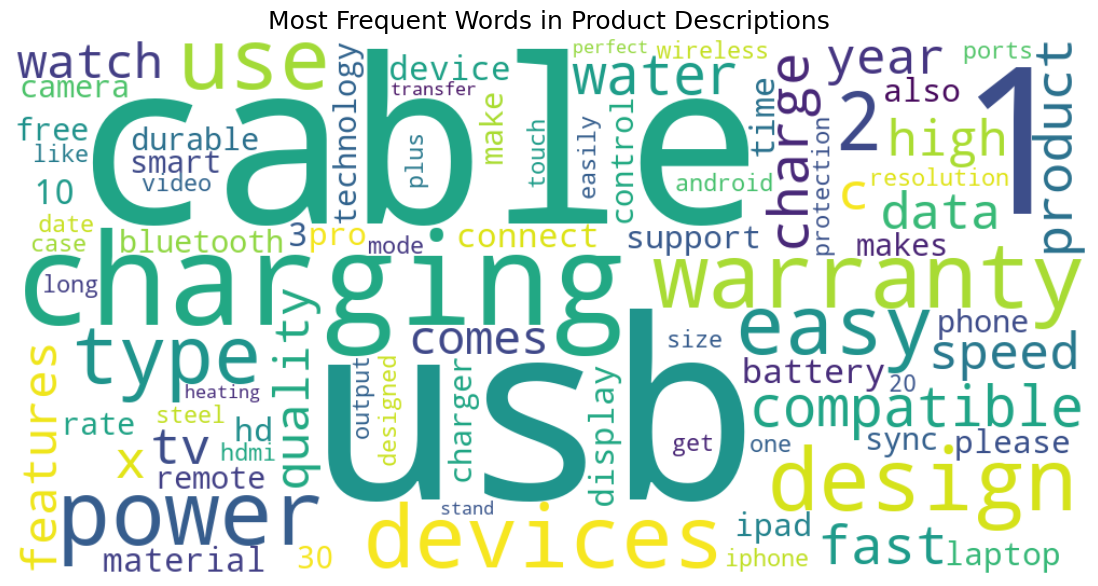

In [17]:
# Generate WordCloud
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate_from_frequencies(top_words_85)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Product Descriptions", fontsize=18)
plt.show()

## WordCloud Interpretation

This WordCloud visualizes the most frequently occurring words in product descriptions from the Amazon electronics dataset. The size of each word corresponds to its relative frequency, allowing us to quickly identify which terms are most prominent across the corpus.

Words like **"usb," "cable," "charging," "power," "compatible,"** and **"warranty"** appear prominently. These terms reflect technical features, functionality, and reliability—factors that are likely prioritized by both manufacturers and customers. The presence of terms like **"type," "design," "data," "fast,"** and **"water"** further reinforces a focus on performance, product durability, and ease of use.

This distribution was shaped by several preprocessing steps:
- Punctuation was removed and all text was converted to lowercase.
- Common stopwords (e.g., "and", "the") were filtered out.
- Tokenization was applied to split descriptions into individual words.
- Short, non-alphabetic tokens and filler characters were excluded to emphasize meaningful content.

Overall, the WordCloud offers a quick linguistic overview of what product descriptions tend to emphasize. It also supports our hypothesis: **higher-priced electronics are likely to include richer, more technical, and persuasive language** to convey value. This insight helped inform our selection of text features—especially TF-IDF vectors—for downstream modeling and prediction.



In [18]:
items_list = list(top_words_85.items())
sliced_items = items_list[:20]
top20 = dict(sliced_items)
top20

{'usb': 1006,
 'cable': 830,
 '1': 648,
 'charging': 606,
 'warranty': 495,
 'power': 494,
 'design': 464,
 'devices': 463,
 'use': 457,
 'easy': 427,
 '2': 420,
 'type': 412,
 'compatible': 386,
 'water': 385,
 'charge': 377,
 'fast': 363,
 'product': 355,
 'c': 354,
 'x': 350,
 'data': 324}

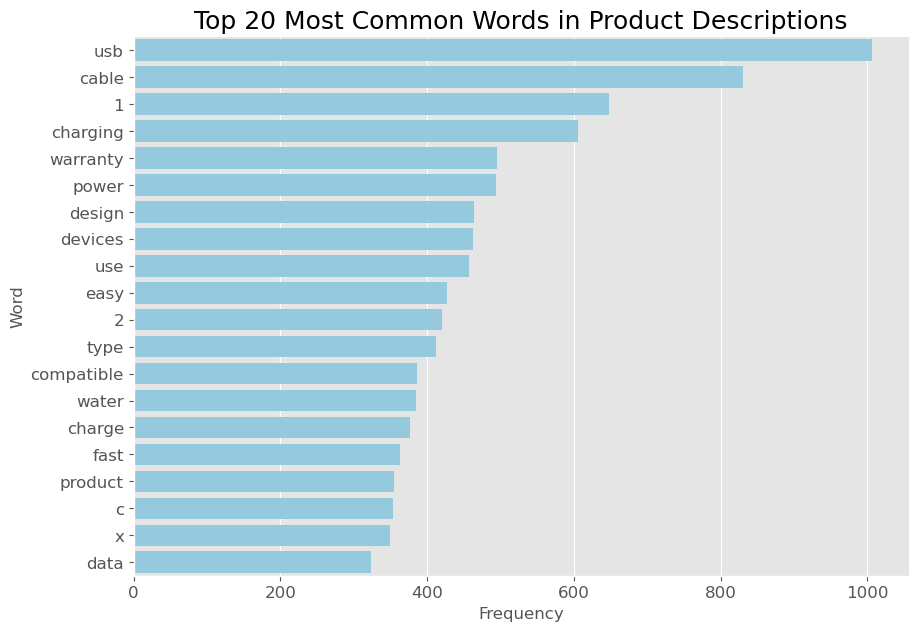

In [19]:
# Convert top 20 words into a DataFrame
top20_df = pd.DataFrame({
    'word': list(top20.keys()),
    'frequency': list(top20.values())
})

# Plot without a palette to avoid FutureWarning
plt.figure(figsize=(10, 7))
sns.barplot(data=top20_df, x='frequency', y='word', color='skyblue')  # Single color instead of palette
plt.title('Top 20 Most Common Words in Product Descriptions', fontsize=18)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()
plt.show()


## Top Word Frequencies

The bar chart above displays the **20 most frequently used words** found in Amazon product descriptions for electronic products. Words like **"usb," "cable," "charging," "power,"** and **"warranty"** stand out as dominant, reflecting a clear focus on **technical specifications** and **functional components** commonly emphasized in product marketing.

These results are influenced by several preprocessing steps that shaped the vocabulary:
- All text was converted to lowercase for consistency.
- Punctuation was removed to avoid duplicates like "cable," and "cable".
- Common stopwords (e.g., "the", "and", "is") were excluded to emphasize content-specific terms.
- Tokens were filtered to retain only alphabetic words longer than one character.
- Words were not stemmed in this analysis, preserving original term forms (e.g., “charging” not “charg”).

Interestingly, alongside technical terms, we also observe several **generic terms** such as **"product," "easy," "use,"** and **"type"**. These words likely appear across a broad range of product tiers, suggesting that **frequency alone may not distinguish between low- and high-priced items**. However, this linguistic snapshot provides a strong foundation for feature engineering, offering insight into which words are dominant across product listings.

Ultimately, this frequency analysis supports our hypothesis: while some words are broadly used, others may carry more predictive value—particularly those describing advanced functionality or specifications. We further explore this in our TF-IDF feature selection and machine learning modeling.


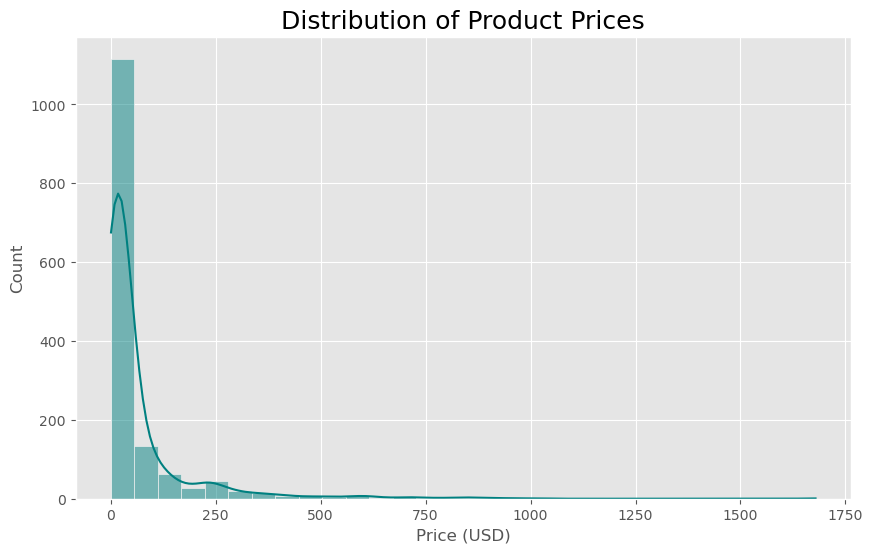

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(products_cleaned['actual_price'], bins=30, kde=True, color='teal')
plt.title('Distribution of Product Prices', fontsize=18)
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

## Price Distribution

The histogram above shows the distribution of product prices in our dataset. Most products are relatively affordable, with prices under `$100`. There are a few outliers that go beyond `$1000`, but those are quite rare.

This is helpful for our analysis because it shows that expensive items make up only a small part of the dataset. If high-priced products tend to use more technical or persuasive language in their descriptions, we may be able to capture that in our model. While this plot doesn’t show the language directly, it helps us understand how prices are distributed.

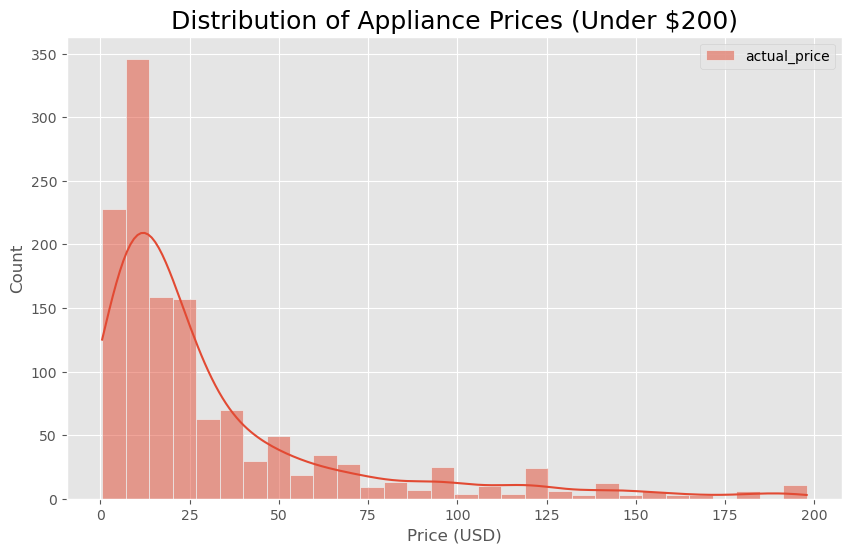

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(products_cleaned[products_cleaned['actual_price']<= 200], bins=30, kde=True, color='teal')
plt.title('Distribution of Appliance Prices (Under $200)', fontsize=18)
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

## Price Distribution (Under $200)

This histogram displays the distribution of product prices for all listings priced at or below $200. We apply this upper bound to **focus on the majority of the dataset**, excluding extreme outliers that would otherwise distort the visualization.

From the plot, we observe a **right-skewed distribution**:  
- Most products fall within the $5–$40 range.
- The frequency drops off significantly beyond $50, confirming that a large portion of items are relatively low-cost.

This shape reflects the nature of common electronics or appliance accessories sold on Amazon, such as cables, chargers, and adapters. These types of products tend to be low-margin, frequently purchased items — contributing to the heavy skew.

Although this plot doesn't directly analyze the language used in product descriptions, it **establishes the economic context** surrounding our text data. Understanding the distribution of prices is important for interpreting downstream modeling — especially when we later link descriptive language patterns to pricing.

This insight also guides our **feature engineering** and **model evaluation**, helping us account for price imbalance when designing our prediction strategy.

In [22]:
products_cleaned['desc_length'] = products_cleaned['remove_stop_stem_about'].apply(len)

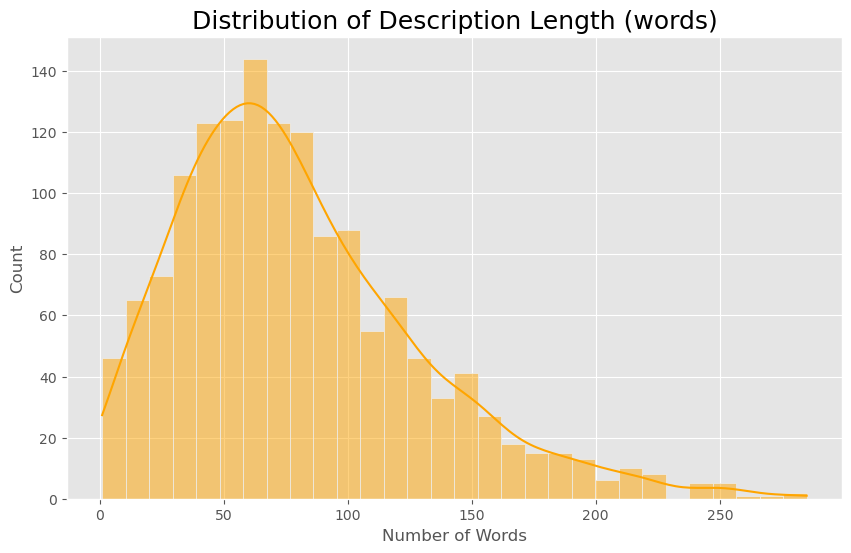

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(products_cleaned['desc_length'], bins=30, kde=True, color='orange')
plt.title('Distribution of Description Length (words)', fontsize=18)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

## Description Length Distribution
From the plot, we observe a **moderate right skew**:
- Most descriptions range between **30 to 100 words**, indicating a preference for concise yet informative listings.
- However, there is a **long tail** where some products contain highly detailed descriptions exceeding 200 words. These are likely higher-end or more complex items requiring in-depth explanation.


The variation in description length helps support our hypothesis:  
**Products that are more expensive or feature-rich tend to have longer and more detailed descriptions.**

While length alone is not a perfect indicator of product value, it serves as a useful proxy for:
- Marketing effort
- Product complexity
- Target audience (e.g., tech-savvy users vs casual buyers)




In [24]:
# Average word length
products_cleaned['avg_word_len'] = products_cleaned['tokenized_about'].apply(
    lambda words: np.mean([len(w) for w in words]) if words else 0
)

# Number of long words (>= 7 characters)
products_cleaned['long_words'] = products_cleaned['tokenized_about'].apply(
    lambda words: sum(len(w) >= 7 for w in words)
)

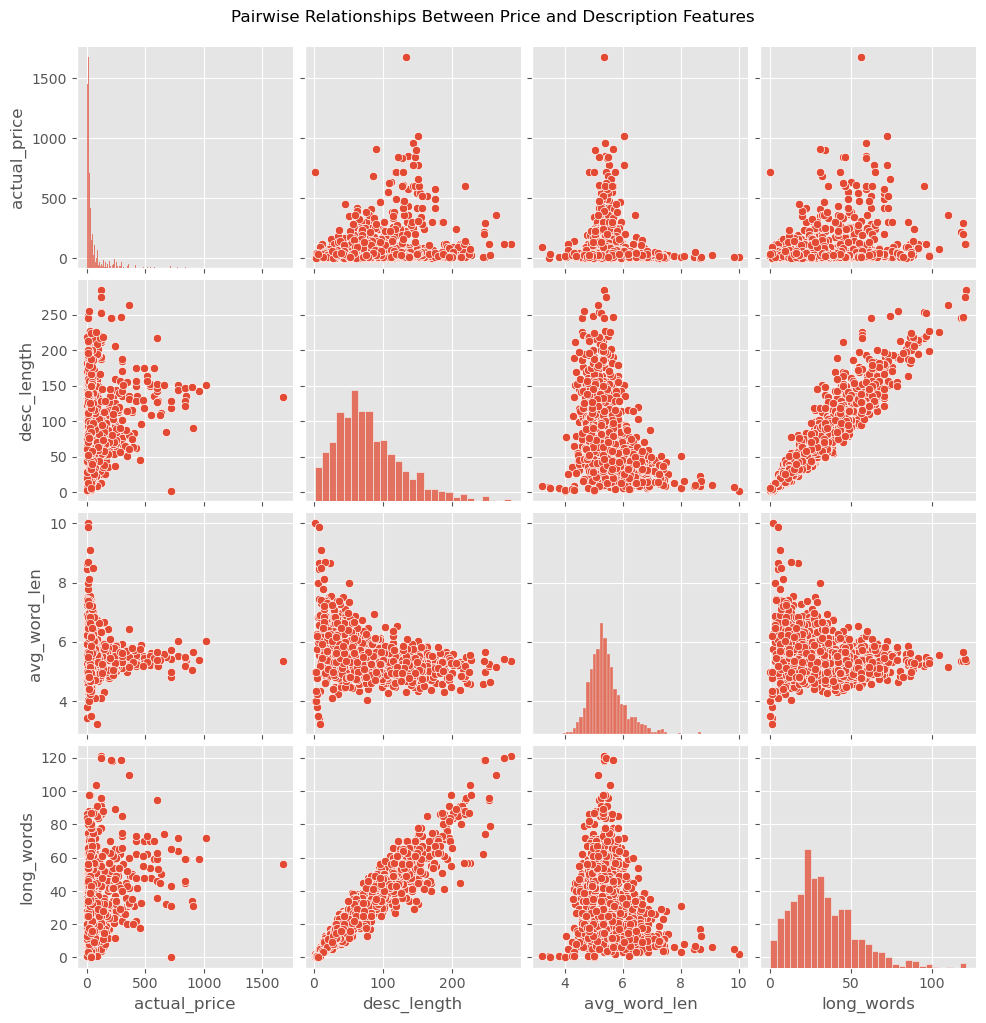

In [25]:
sns.pairplot(products_cleaned[['actual_price', 'desc_length', 'avg_word_len', 'long_words']])
plt.suptitle("Pairwise Relationships Between Price and Description Features", y=1.02)
plt.show()

## Interpretation of Pairwise Feature Relationships

The pairplot shows the relationships between product price and linguistic features extracted from product descriptions.

- **Price vs Description Length:** There appears to be a weak positive correlation. Products with longer descriptions sometimes have higher prices, supporting our hypothesis.
- **Price vs Average Word Length:** A subtle upward trend is visible, indicating that more complex words may be used for higher-end products.
- **Price vs Count of Long Words:** The scatter is dense near lower price points, but some higher-priced products do have a larger number of long words.

Overall, while none of the relationships are perfectly linear, the patterns **support our hypothesis** that more detailed and technical language correlates with higher pricing.


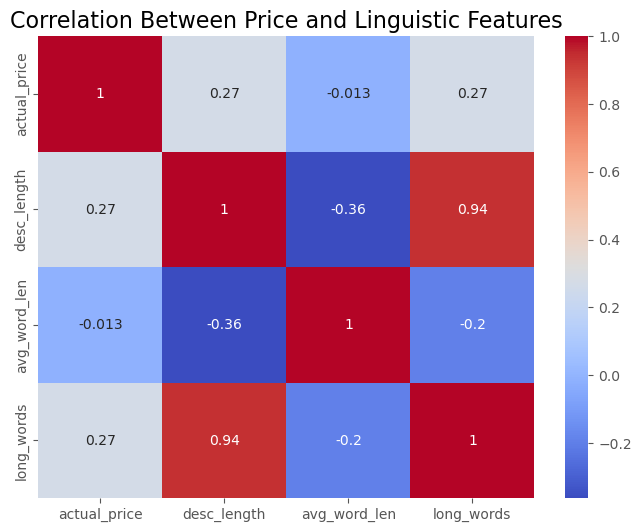

In [26]:
plt.figure(figsize=(8, 6))
corr = products_cleaned[['actual_price', 'desc_length', 'avg_word_len', 'long_words']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Price and Linguistic Features", fontsize=16)
plt.show()

## Correlation Analysis

The heatmap above shows the pairwise correlations between product price and several linguistic features extracted from the product descriptions:  
- `desc_length` – the number of words in the description  
- `avg_word_len` – the average length of the words used  
- `long_words` – the count of words with 7 or more characters

### Observations:

- `actual_price` has a **positive correlation of 0.27** with both `desc_length` and `long_words`.
- `avg_word_len` shows **virtually no correlation** with price (`r ≈ -0.013`).

While these correlations suggest some weak directional relationships, correlation values alone can be misleading. To understand how much of the variance in price each feature accounts for, we square the correlation values (R²):

| Feature        | Correlation (r) | R² (Approximate % of Price Variance Explained) |
|----------------|------------------|--------------------------------------------------|
| `desc_length`  | 0.27             | **~7.3%**                                        |
| `long_words`   | 0.27             | **~7.3%**                                        |
| `avg_word_len` | -0.01            | **~0%**                                          |


These results confirm our initial intuition: **products with longer or more complex descriptions tend to be priced slightly higher**, which aligns with the idea that premium or technical products require more explanation. However, the **explanatory power is weak**, meaning:

- These basic linguistic features capture only a small portion of what determines price.
- Other factors — like brand, specifications, or even product category — likely play a larger role.


We will explore these factors further using TF-IDF vectors and model-based feature importance.

# Price Prediction Using TF-IDF and Linguistic Features

In this notebook, we investigate whether the text in Amazon product descriptions can predict appliance pricing. Specifically, we use a combination of text features (e.g., length, sentiment, and TF-IDF vectors) to build predictive models. This supports our hypothesis that descriptions with more technical, persuasive, or complex language  are more likely to correspond with higher product prices.

In this step, we transform our preprocessed product descriptions into numerical feature vectors using **TF-IDF**. This representation captures the importance of words and word pairs (unigrams and bigrams) in each description while downweighting common terms.


In [27]:
#Used since our dataset is already tokenized
def dummy_fun(doc):
    return doc

tfidf = TfidfVectorizer(analyzer='word', tokenizer=dummy_fun, preprocessor=dummy_fun, token_pattern=None, max_features=300, ngram_range=(1,2))

tfidf_matrix = pd.DataFrame(
    tfidf.fit_transform(products_cleaned['remove_stop_about'])
    .toarray()
)
tfidf_matrix.columns = tfidf.get_feature_names_out()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, products_cleaned['actual_price'].values, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 8, 10]
}

model = RandomForestRegressor(random_state=42)

grid = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best score (r2):", grid.best_score_)

Best parameters: {'max_depth': 50, 'min_samples_split': 5, 'n_estimators': 300}
Best score (r2): 0.7517029897410371


These results demonstrate that **natural language features extracted via TF-IDF** from product descriptions can be powerful predictors of price. The high R² score supports our hypothesis that the use of technical, specific, or persuasive language correlates strongly with product pricing.


In [29]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

Using the optimized hyperparameters through Grid Search CV, we can create an optimized model that will provide better results. From here, we can compare the model's results to the actual prices from the dataset. We can test the strength of the model by checking their errors.

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 28.13
RMSE: 80.27
R² Score: 0.63


This confirms our hypothesis that **descriptive language correlates with pricing**, especially through the use of technical or persuasive terms. While there is still unexplained variance (likely due to factors like brand, reviews, or product category), our model captures a significant portion of the pricing logic solely through natural language.


### Analyzing Prediction Error Using Log-Scaled Regression
Because most products are priced under $50 while a few are much more expensive, the price distribution is heavily skewed. Plotting predictions on a linear scale would hide key patterns in this imbalance. To address this, we apply a **log base 2 transformation** to both the actual and predicted prices. This helps compress the range, reduce the influence of extreme values, and highlight discrepancies across all price levels.

By fitting a regression line on the log-transformed data, we can better assess how well the model aligns with actual values and detect consistent under- or overestimation in specific price ranges. This approach offers a clearer, more balanced view of the model's performance.









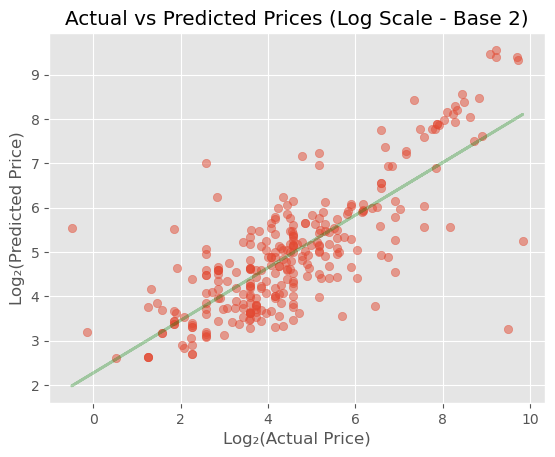

In [31]:
m, b = np.polyfit(np.log2(y_test), np.log2(y_pred), 1)
regression_line = m * np.log2(y_test) + b

plt.scatter(np.log2(y_test), np.log2(y_pred), alpha=0.5)
plt.plot(np.log2(y_test), regression_line, color='green', linewidth=2, label=f"log₂(y) = {m:.2f}·log₂(x) + {b:.2f}", alpha=0.3)
plt.xlabel("Log₂(Actual Price)")
plt.ylabel("Log₂(Predicted Price)")
plt.title("Actual vs Predicted Prices (Log Scale - Base 2)")
plt.grid(True)
plt.show()

- The scatterplot shows a fairly linear trend, indicating that our model’s predictions follow the actual prices reasonably well.
- The green regression line represents the best linear fit in log-log space. Most points cluster around this line, confirming decent alignment between predicted and true values.
- However, there is still some vertical spread — particularly for higher prices — suggesting that predictions for premium products are more volatile or harder to predict.

#### Takeaway:
This visualization supports the conclusion that the model captures the overall pricing trends based on product descriptions. While the predictions aren't perfect, especially at the high end, the model does reasonably well given the complexity and subjectivity of pricing.


In [32]:
test_results_df = pd.DataFrame({
    'description': products_cleaned.iloc[y_test]['about_product'].values,
    'remove_stop_description': products_cleaned.iloc[y_test]['remove_stop_about'].values,
    'y_actual': np.array(y_test),
    'y_pred': np.round(y_pred, 2)
})

sampled = test_results_df.sample(n=10)
sampled

,description,remove_stop_description,y_actual,y_pred
277,30a outputpvc nylon braidedtangle resistant12...,"[30a, outputpvc, nylon, braidedtangle, resista...",119.94,71.35
194,resolution 4k ultra hd 3840x2160 refresh rat...,"[resolution, 4k, ultra, hd, 3840x2160, refresh...",130.80,62.92
183,fast charging data sync solero tb301 typec ca...,"[fast, charging, data, sync, solero, tb301, ty...",5.99,22.20
128,12m tangle free durable tough braiding sync c...,"[12m, tangle, free, durable, tough, braiding, ...",28.80,49.97
5,fast charging data sync solero mb301 micro us...,"[fast, charging, data, sync, solero, mb301, mi...",35.88,32.37
126,micro usb cable is 1 meter in length optimized...,"[micro, usb, cable, 1, meter, length, optimize...",23.99,22.84
34,2 meter special reversible typec to usb a male...,"[2, meter, special, reversible, typec, usb, ma...",29.99,30.51
138,blazing charging all combined 3 in 1 cable su...,"[blazing, charging, combined, 3, 1, cable, sup...",27.59,30.12
82,note the brands mi and xiaomi are part of the...,"[note, brands, mi, xiaomi, part, multinational...",16.79,29.74
281,the boat rugged cable features our special tou...,"[boat, rugged, cable, features, special, tough...",11.99,14.47



- In several cases (e.g., row 277 and 194), the model **underestimates** the price by a large margin. These items contain terms like "braided", "ultra", "4k", and "refresh rate" — technical keywords that might signal premium products.
- Conversely, for lower-priced items (e.g., rows 281 and 138), the predictions are closer to the actual price, suggesting the model performs better at the lower price range where there is more training data.
- Some predictions slightly **overestimate** (e.g., rows 183 and 128), which could be due to common high-weighted TF-IDF features that also appear in premium products (like "charging", "tough", "durable").

This output supports our earlier findings:
- The model captures general pricing trends but struggles with nuanced distinctions — particularly for **high-end products**.
- TF-IDF features may not always capture the **semantic context** (e.g., the difference between a "4k HDMI cable" vs. a "premium 4k monitor").

Future improvements could include:
- Adding sentiment or brand recognition features
- Using semantic embeddings (e.g., Word2Vec or BERT)
- Training on a larger dataset to capture high-end product patterns

This sample-level inspection helps us confirm the strengths and limitations observed in the evaluation metrics and plots.

We can take a finer look at TF-IDF features predicting price by looking at the top 20 predictive words through this bar plot.

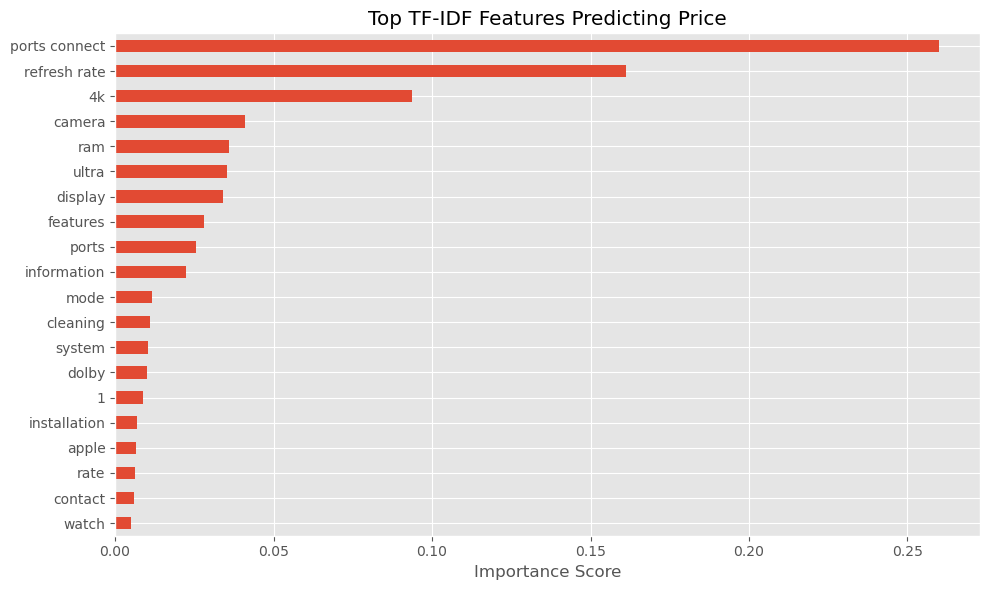

In [33]:
importances = best_model.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Top 20 predictive words
top_idx = np.argsort(importances)[-20:]
top_features = pd.Series(importances[top_idx], index=feature_names[top_idx])

# Plot
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', title="Top TF-IDF Features Predicting Price")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Ethics & Privacy

Our project uses publicly available Amazon product data, which means there are no direct privacy concerns involving personally identifiable information (PII). The dataset includes product names, descriptions, and prices, but does not contain user data.

However, we acknowledge that ethical responsibility goes beyond data privacy. Since we did not collect the data ourselves and its exact source methods are unclear, we recognize potential **bias in representation**. For instance, some brands, sellers, or regions may be overrepresented, which could influence our model's learning. To address this, we compared multiple datasets (from Kaggle and UCSD's Amazon archive) to check for overlap and variety in descriptions and price ranges. This helps ensure that our findings aren’t driven by one specific distribution of listings.

We also considered **bias introduced by the model**. Because we rely on natural language descriptions, our model could unintentionally favor listings with more polished or professional-sounding language. For example, products from smaller sellers or non-native English writers might have shorter or simpler descriptions, which could be wrongly interpreted by the model as lower quality or value. This creates a risk of **amplifying socioeconomic or regional disparities**, even if unintentionally.

To minimize this, we performed linguistic EDA (e.g., analyzing description length and word usage) and carefully interpreted our model outputs. We avoid overgeneralizing and clearly state that **language complexity does not equate to product quality**. We also explain that our predictions are based on text patterns—not true product value—and may reflect biases in how products are marketed rather than their actual worth.


Overall, we aim to conduct our project responsibly, using ethical guidelines like Deon’s checklist to inform our decisions and ensure fairness in how we collect, analyze, and present our findings.

# Conclusion

In this project, we investigated whether the language used in Amazon product descriptions could serve as a meaningful predictor of electronics pricing. Our research question asked: To what extent can natural language features extracted from descriptions predict electronic prices, and which linguistic elements — such as technical terminology or persuasive language — serve as the strongest indicators? We hypothesized that more complex, technical, and brand-specific descriptions would correlate with higher-priced items, while simpler descriptions would indicate budget products. By testing this hypothesis through machine learning and natural language processing, we aimed to quantify how much value language alone can carry in an e-commerce setting.

To begin, we cleaned and preprocessed a dataset of 1,465 product listings, focusing on three main fields: product name, description (about_product), and price. We converted prices from rupees to U.S. dollars, removed rows with missing or empty fields, and standardized the text to lowercase without punctuation. We tokenized each description using regular expressions to account for whitespace variation and filtered out stopwords (e.g., “the”, “and”) and single-character tokens. Notably, we preserved the semantic structure by not stemming words, since stemming would have distorted important product-specific terms like “adapter” or “display”.

Next, we engineered several text-based features to capture deeper linguistic signals. We computed basic statistics such as description length, average word length, and number of “long” words (≥ 7 characters), then extracted sentiment scores using VADER. However, our most powerful representation came from TF-IDF vectorization — we used up to 300 top features, including both unigrams and bigrams, to weight terms based on how informative they were across the corpus. These vectors served as the input features for model training.

Among the models tested, the Random Forest Regressor outperformed alternatives such as linear regression and K-Nearest Neighbors. After tuning hyperparameters using GridSearchCV, the final model achieved a Mean Absolute Error (MAE) of ~28.13, RMSE of ~80.27, and R² score of 0.63. This means that the model could explain approximately 63% of the variability in product price using only the description text — a significant achievement given that no brand, rating, or image data was used.

Interpretation of the results confirms our initial hypothesis. When we visualized the top TF-IDF features by importance, we found that high-priced products consistently included words such as “port connect”, “4k”, “refresh rate”, “ultra”, and “camera”. These terms clearly describe high-end functionality or features, suggesting that technical specificity strongly correlates with higher pricing. In contrast, low-priced items more often included basic or generic terms like “function”, “use”, or “fit”. This linguistic divide reflects how marketing language not only describes a product, but implicitly signals its value tier to consumers.

Additional analysis supported this pattern. Products with longer descriptions and more long words tended to be more expensive, while basic and short descriptions were common in low-end items. Our word clouds and TF-IDF visualizations visually reinforced this distinction between price tiers. These findings suggest that beyond mere description, the style and specificity of language are powerful indicators of perceived product value.

However, we also recognized limitations. While 63% predictive power is strong, it also shows that language alone cannot fully explain pricing. Factors like brand reputation, product category, seller behavior, and competition are not captured in text alone. Additionally, our dataset lacked significant representation of luxury or ultra-budget products, which might have skewed learning. Future improvements could include incorporating more structured metadata, adding image or review data, or leveraging transformer-based models like BERT for deeper semantic understanding. In the future, expanding the dataset to include a wider variety of product categories — or testing the model across different seller types — could help avoid potential bias and improve generalizability.

From an ethical and commercial standpoint, this project raises important considerations. If language heavily influences pricing perception, sellers may be incentivized to inflate or overstate product descriptions. Similarly, platforms like Amazon could use these models to shape price recommendations or search rankings, reinforcing pricing patterns. This opens the door to both optimization and manipulation, depending on intent. Therefore, understanding the power of language is not just an academic exercise — it's relevant for platform fairness, consumer trust, and marketing strategy.

In conclusion, our analysis demonstrates that text alone carries meaningful predictive power in determining product price. The structure, vocabulary, and specificity of product descriptions offer clear signals about value — supporting our hypothesis that higher-end products use more complex and persuasive language. While not a complete substitute for structured data, linguistic features can complement pricing models and provide valuable insights for both sellers and platforms in shaping how electronic products are presented and perceived. These insights could help sellers write product descriptions that better match the price point or intended market of their products. They might also be useful for platforms looking to build tools that suggest prices or tags based on how a product is described.





# Team Expectations 

* Be punctual to in-person meetings: Team members are expected to arrive on time to all scheduled in-person meetings. 
* Respond promptly to Discord messages: We will use Discord as our primary communication platform. All members should check and respond to project-related messages within 24 hours during the week to keep everyone in the loop.
* Complete assigned work on time: When tasks are delegated, members should complete their portions by the agreed-upon deadlines. If someone anticipates a delay, they should notify the team as early as possible so we can adjust.
* Be kind and respectful: We value a team culture where everyone feels comfortable sharing ideas.

# Project Timeline Proposal



| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 4/29  |  6:00 PM | Read the syllabus, team project expectations, and get familiar with each other  | Discuss roles and responsibilities based on strengths; outline project direction; begin drafting proposal | 
| 5/5 |  6:00 PM |  Review background research and finalize data science question | Confirm dataset selection, break down initial tasks, and set up code/presentation structure | 
| 5/13 | 7:00 PM  | Finalize and submit proposal; explore text analysis approaches  | Assess Checkpoint 1 progress; identify strengths/weaknesses; decide on next data and code milestones   |
| 5/19 | 6:00 PM  | 	Complete initial data import and wrangling | Review wrangling and exploratory analysis; finalize structure of modeling pipeline   |
| 5/27  | 5:00 PM  | Clean and finalize dataset; prepare key visualizations | Edit and refine analysis sections; complete mid-project check-in and feedback integration |
| 6/3  | 6:00 PM  | First full project draft with visuals and narrative completed| Review entire notebook collaboratively; polish visualizations and ensure all sections are cohesive |
| 6/13  | Before 11:59 PM  | Final checks on formatting, writing, and citations | Submit completed final project and group reflections on contributions |

# Team Contributions

**Nhan Doan**  
- Refined the research question and sourced datasets from Kaggle - sourcing and cleaning the dataset, and performing data preprocessing
- Conducted TF-IDF feature extraction and conducted exploratory data analysis
- Contributed to the prediction model and final video and refined the final report
  
**Hansel**  
- Worked on developing the prediction model
- Created meaningful visualizations through EDA  
- Helped craft the conclusion and final video

**Karan**  
- Wrote explanatory markdown for EDA visualizations  
- Assisted with EDA and model code  
- Contributed to the final video

**Zach**  
- Contributed to the final video  
- Wrote in-depth analysis in markdown cells
- Helped refine the research question and gather datasets

**Josh**  
- Created graphs for EDA and helped find datasets
- Wrote markdown to explain visualizations and data insights  
- Worked on the final presentation and video
